<a href="https://colab.research.google.com/github/Helothlad/Monte-Carlo-simulations/blob/main/Financial-growth-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
from dataclasses import dataclass
import pandas as pd
%matplotlib inline
import random
import statsmodels.api as sm


In [35]:
@dataclass
class ModelInputs:
  starting_salary: int = 60000
  promos_every_n_years: int = 5
  cost_of_living_raise: float = 0.02
  promo_raise: float = 0.15
  savings_rate: float = 0.25
  interest_rate: float = 0.05
  desired_cash: int = 1500000
model_data = ModelInputs()
model_data

ModelInputs(starting_salary=60000, promos_every_n_years=5, cost_of_living_raise=0.02, promo_raise=0.15, savings_rate=0.25, interest_rate=0.05, desired_cash=1500000)

In [36]:
def salary_at_year(data: ModelInputs, year):
  num_promos = int(year / data.promos_every_n_years)

  salary_t = data.starting_salary * (1 + data.cost_of_living_raise) ** year * (1+data.promo_raise) ** num_promos

  return salary_t

In [37]:
for i in range(6):
  year = i + 1
  salary = salary_at_year(model_data, year)
  print(f'The salary at year {year} is ${salary:,.0f}.')

The salary at year 1 is $61,200.
The salary at year 2 is $62,424.
The salary at year 3 is $63,672.
The salary at year 4 is $64,946.
The salary at year 5 is $76,182.
The salary at year 6 is $77,705.


In [38]:
def cash_saved_during_year(data: ModelInputs, year):
  salary = salary_at_year(data,year)
  cash_saved = salary * data.savings_rate
  return cash_saved

In [39]:
def wealth_at_year(data: ModelInputs, year, prior_wealth):
  cash_saved = cash_saved_during_year(data, year)
  wealth = prior_wealth * (1 + data.interest_rate) + cash_saved
  return wealth

In [40]:
prior_wealth = 0
for i in range(6):
  year = i + 1
  wealth = wealth_at_year(model_data, year, prior_wealth)
  print(f'Wealth at year {year} is ${wealth:,.0f}.')
  prior_wealth = wealth

Wealth at year 1 is $15,300.
Wealth at year 2 is $31,671.
Wealth at year 3 is $49,173.
Wealth at year 4 is $67,868.
Wealth at year 5 is $90,307.
Wealth at year 6 is $114,248.


In [41]:
def years_to_retirement(data: ModelInputs, print_output=True):
  prior_wealth = 0
  wealth = 0

  year = 0

  if print_output:
    print('Wealths over time:')
  while wealth < data.desired_cash:
    year = year + 1
    wealth = wealth_at_year(data, year, prior_wealth)
    if print_output:
      print(f'The wealth at year {year} is ${wealth:,.0f}.')

  if print_output:
    print(f'\nRetirement:\nIt will take {year} years to retire.')

  return year

In [42]:
years = years_to_retirement(model_data)

Wealths over time:
The wealth at year 1 is $15,300.
The wealth at year 2 is $15,606.
The wealth at year 3 is $15,918.
The wealth at year 4 is $16,236.
The wealth at year 5 is $19,045.
The wealth at year 6 is $19,426.
The wealth at year 7 is $19,815.
The wealth at year 8 is $20,211.
The wealth at year 9 is $20,615.
The wealth at year 10 is $24,182.
The wealth at year 11 is $24,665.
The wealth at year 12 is $25,159.
The wealth at year 13 is $25,662.
The wealth at year 14 is $26,175.
The wealth at year 15 is $30,703.
The wealth at year 16 is $31,318.
The wealth at year 17 is $31,944.
The wealth at year 18 is $32,583.
The wealth at year 19 is $33,234.
The wealth at year 20 is $38,984.
The wealth at year 21 is $39,764.
The wealth at year 22 is $40,559.
The wealth at year 23 is $41,370.
The wealth at year 24 is $42,198.
The wealth at year 25 is $49,498.
The wealth at year 26 is $50,488.
The wealth at year 27 is $51,497.
The wealth at year 28 is $52,527.
The wealth at year 29 is $53,578.
The 

In [43]:
def get_salaries_wealths_df(data):
  prior_wealth = 0
  wealth = 0

  year = 0

  df_data_tups = []
  while wealth < data.desired_cash:
    year = year + 1
    salary = salary_at_year(data, year)
    wealth = wealth_at_year(data, year, prior_wealth)

    prior_wealth = wealth

    df_data_tups.append((year, salary, wealth))

  df  = pd.DataFrame(df_data_tups, columns=['Year', 'Salary', 'Wealth'])

  return df


In [44]:
def styled_salaries_wealths(df):
    return df.style.format({
        'Salary': '${:,.2f}',
        'Wealth': '${:,.2f}'
    })

In [45]:
df = get_salaries_wealths_df(model_data)
styled_salaries_wealths(df)

,Year,Salary,Wealth
0,1,"$61,200.00","$15,300.00"
1,2,"$62,424.00","$31,671.00"
2,3,"$63,672.48","$49,172.67"
3,4,"$64,945.93","$67,867.79"
4,5,"$76,181.58","$90,306.57"
5,6,"$77,705.21","$114,248.20"
6,7,"$79,259.31","$139,775.44"
7,8,"$80,844.50","$166,975.33"
8,9,"$82,461.39","$195,939.45"
9,10,"$96,727.21","$229,918.22"


<Axes: xlabel='Year'>

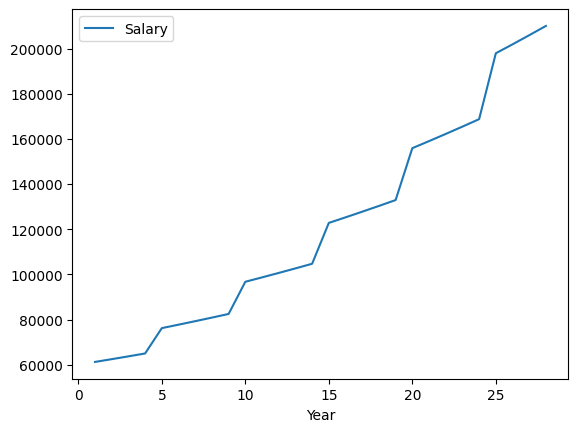

In [46]:
df.plot.line(x='Year', y='Salary')

<Axes: xlabel='Year'>

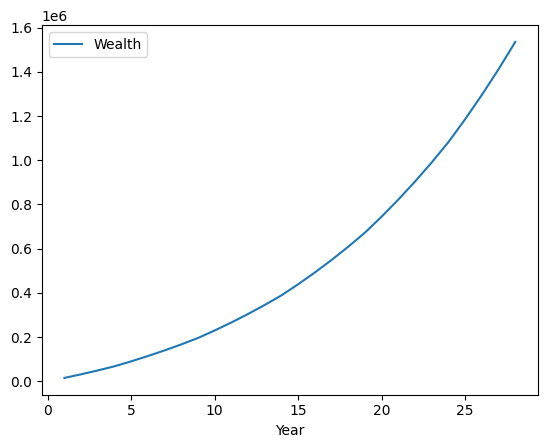

In [47]:
df.plot.line(x='Year', y='Wealth')

<Axes: xlabel='Year'>

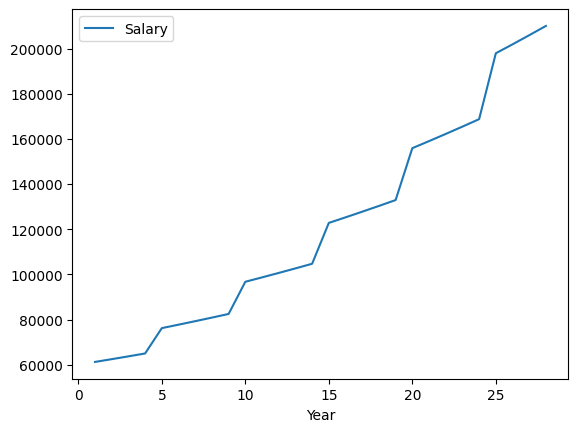

In [48]:
df.plot.line(x='Year', y='Salary')

In [49]:
@dataclass
class SimulationInputs:
  n_iterations: int = 10000
  starting_salary_std: int = 10000
  promos_every_n_years_std: int = 1.5
  cost_of_living_raise_std: float = 0.005
  promo_raise_std: float = 0.05
  savings_rate_std: float = 0.07
  interest_rate_std: float = 0.01
sim_data = SimulationInputs()

In [50]:
def random_normal_positive(mean, std):
  drawn_value = -1
  while drawn_value < 0:
    drawn_value = random.normalvariate(mean, std)
  return drawn_value

In [51]:
def years_to_retirement_simulation_inputs(data, sim_data):
  starting_salary = random_normal_positive(data.starting_salary, sim_data.starting_salary_std)
  promos_every_n_years = random_normal_positive(data.promos_every_n_years, sim_data.promos_every_n_years_std)
  cost_of_living_raise = random_normal_positive(data.cost_of_living_raise, sim_data.cost_of_living_raise_std)
  promo_raise = random_normal_positive(data.promo_raise, sim_data.promo_raise_std)
  savings_rate = random_normal_positive(data.savings_rate, sim_data.savings_rate_std)
  interest_rate = random_normal_positive(data.interest_rate, sim_data.interest_rate_std)
  return (
        starting_salary,
        promos_every_n_years,
        cost_of_living_raise,
        promo_raise,
        savings_rate,
        interest_rate,
    )


In [52]:
def years_to_retirement_single_simulation(data, sim_data):
  (
        starting_salary,
        promos_every_n_years,
        cost_of_living_raise,
        promo_raise,
        savings_rate,
        interest_rate,
    ) = years_to_retirement_simulation_inputs(data, sim_data)
  new_data = ModelInputs(
        starting_salary=starting_salary,
        promos_every_n_years=promos_every_n_years,
        cost_of_living_raise=cost_of_living_raise,
        promo_raise=promo_raise,
        savings_rate=savings_rate,
        interest_rate=interest_rate,
    )
  ytr = years_to_retirement(new_data, print_output=False)

  return (
        starting_salary,
        promos_every_n_years,
        cost_of_living_raise,
        promo_raise,
        savings_rate,
        interest_rate,
        ytr
    )

In [53]:
years_to_retirement_single_simulation(model_data, sim_data)

(49432.15613348426,
 2.8464269154833457,
 0.02181177021110251,
 0.19619579529304984,
 0.17298948084779758,
 0.04676765955706936,
 63)

In [54]:
def years_to_retirement_mc(data, sim_data):
    """
    Runs the full Monte Carlo simulation using years_to_retirement_single_simulation for
    the n_iterations in the SimulationData.

    Outputs a DataFrame containing the inputs values as well as the years to retirement.
    """
    all_results = [years_to_retirement_single_simulation(data, sim_data) for i in range(sim_data.n_iterations)]
    df = pd.DataFrame(
        all_results,
        columns=[
            'Starting Salary',
            'Promotions Every $N$ Years',
            'Cost of Living Raise',
            'Promotion Raise',
            'Savings Rate',
            'Interest Rate',
            'Years to Retirement'
        ]
    )
    return df

In [55]:
df = years_to_retirement_mc(model_data, sim_data)

In [56]:
df

,Starting Salary,Promotions Every $N$ Years,Cost of Living Raise,Promotion Raise,Savings Rate,Interest Rate,Years to Retirement
0,54706.543207,1.921579,0.018540,0.133854,0.272052,0.044437,56
1,55352.414928,7.050962,0.023092,0.135310,0.269605,0.042156,114
2,46762.782968,6.455162,0.019010,0.194119,0.136447,0.052544,121
3,65907.226398,5.001689,0.023044,0.170360,0.131451,0.047313,96
4,41988.694677,4.497820,0.022923,0.169268,0.181278,0.049546,95
...,...,...,...,...,...,...,...
9995,52476.475727,4.624019,0.018066,0.220278,0.236207,0.067118,79
9996,71025.876361,3.190686,0.023941,0.076618,0.172274,0.049806,104
9997,40736.018090,6.142557,0.014824,0.101990,0.300372,0.072970,160
9998,47989.580690,3.351632,0.018218,0.116654,0.120149,0.059113,111


In [57]:
def styled_df(df):
    """
    Styles DataFrames containing the inputs and years to retirement.
    """
    return df.style.format({
        'Starting Salary': '${:,.0f}',
        'Promotions Every $N$ Years': '{:.1f}',
        'Cost of Living Raise': '{:.2%}',
        'Promotion Raise': '{:.2%}',
        'Savings Rate': '{:.2%}',
        'Interest Rate': '{:.2%}',
        'Years to Retirement': '{:.0f}'
    }).background_gradient(cmap='RdYlGn_r', subset='Years to Retirement')

In [58]:
print(f'{len(df)} simulations were run.')

10000 simulations were run.


In [59]:
styled_df(df.head())

,Starting Salary,Promotions Every $N$ Years,Cost of Living Raise,Promotion Raise,Savings Rate,Interest Rate,Years to Retirement
0,"$54,707",1.9,1.85%,13.39%,27.21%,4.44%,56
1,"$55,352",7.1,2.31%,13.53%,26.96%,4.22%,114
2,"$46,763",6.5,1.90%,19.41%,13.64%,5.25%,121
3,"$65,907",5.0,2.30%,17.04%,13.15%,4.73%,96
4,"$41,989",4.5,2.29%,16.93%,18.13%,4.95%,95


np.float64(103.3184)

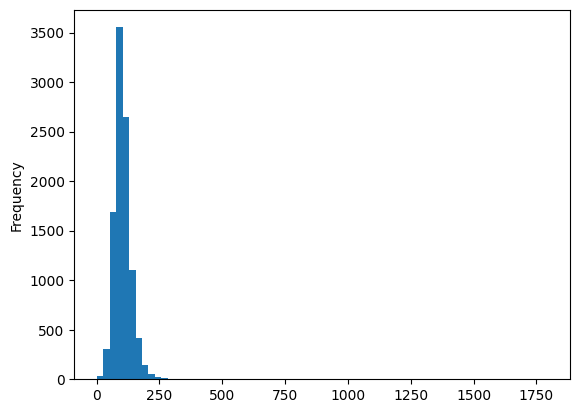

In [60]:
df['Years to Retirement'].plot.hist(bins=70)
df['Years to Retirement'].mean()

In [61]:
quants = df.quantile([i / 20 for i in range(1,20)])
styled_df(quants)

,Starting Salary,Promotions Every $N$ Years,Cost of Living Raise,Promotion Raise,Savings Rate,Interest Rate,Years to Retirement
0.050000,"$43,392",2.5,1.18%,6.71%,13.61%,3.33%,58
0.100000,"$47,201",3.1,1.36%,8.44%,16.27%,3.70%,66
0.150000,"$49,444",3.4,1.48%,9.75%,17.81%,3.93%,72
0.200000,"$51,350",3.8,1.57%,10.72%,19.21%,4.13%,77
0.250000,"$53,154",4.0,1.66%,11.58%,20.34%,4.30%,81
0.300000,"$54,676",4.2,1.73%,12.26%,21.40%,4.45%,85
0.350000,"$56,058",4.4,1.80%,12.95%,22.45%,4.59%,89
0.400000,"$57,375",4.6,1.87%,13.60%,23.28%,4.73%,92
0.450000,"$58,748",4.8,1.94%,14.26%,24.19%,4.86%,96
0.500000,"$60,041",5.0,2.00%,14.88%,25.12%,4.99%,99


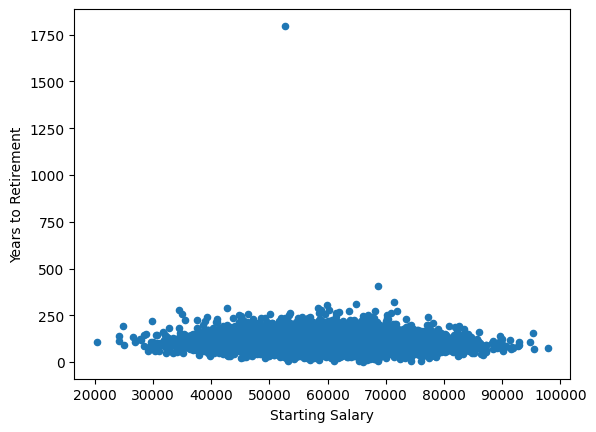

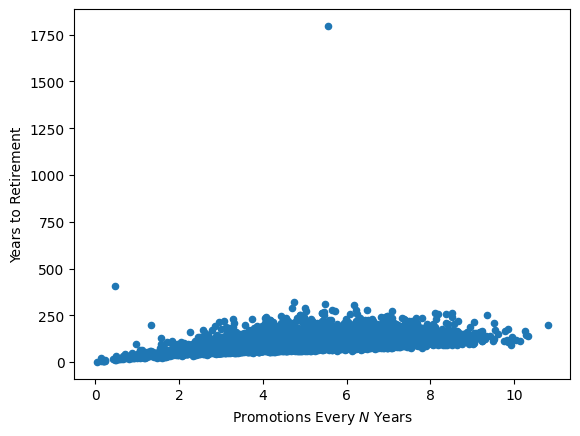

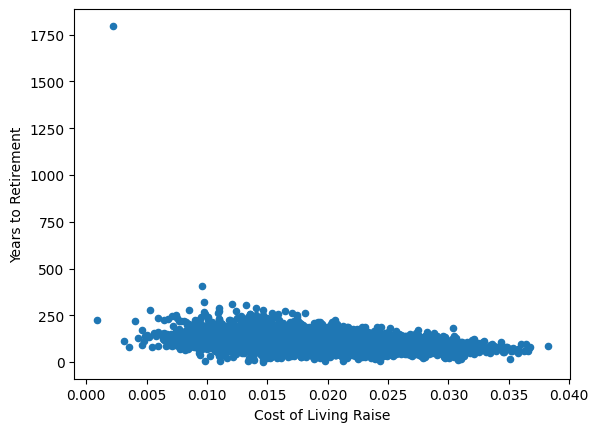

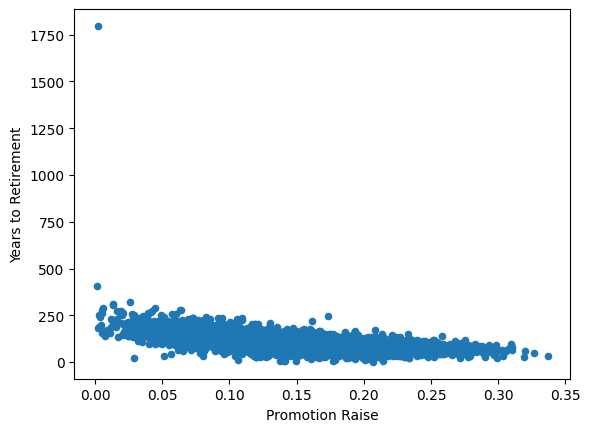

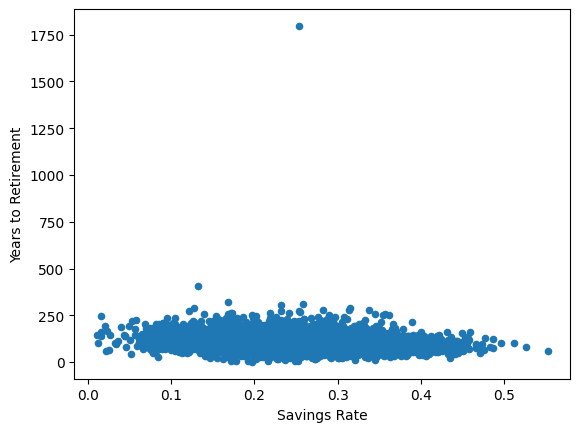

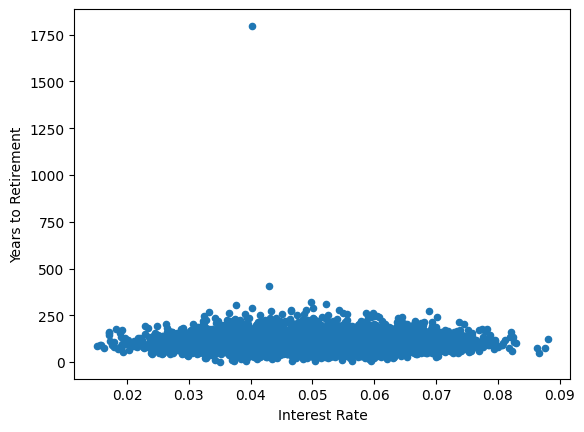

In [64]:
input_cols = [
    'Starting Salary',
    'Promotions Every $N$ Years',
    'Cost of Living Raise',
    'Promotion Raise',
    'Savings Rate',
    'Interest Rate',
]

for col in input_cols:
    df.plot.scatter(y='Years to Retirement', x=col)

In [65]:
output_col = 'Years to Retirement'

x = sm.add_constant(df[input_cols])
y = df[output_col]

mod = sm.OLS(y, x)
result = mod.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Years to Retirement   R-squared:                       0.722
Model:                             OLS   Adj. R-squared:                  0.722
Method:                  Least Squares   F-statistic:                     4323.
Date:                 Wed, 19 Nov 2025   Prob (F-statistic):               0.00
Time:                         17:26:58   Log-Likelihood:                -43960.
No. Observations:                10000   AIC:                         8.793e+04
Df Residuals:                     9993   BIC:                         8.798e+04
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        200.7784      2.060     97.452      0.000     196.740     204.817
Starting Salary               -0.0004   1.96e-05    -19.480      0.000      -0.000      -0.000
Promotions Every $N$ Years    12.3087      0.130     94.593      0.000      12.054      12.564
Cost of Living Raise       -2474.7644     39.425    -62.771      0.000   -2552.046   -2397.483
Promotion Raise             -415.3379      3.895   -106.637      0.000    -422.973    -407.703
Savings Rate                 -95.1868      2.805    -33.938      0.000    -100.685     -89.689
Interest Rate                -15.7905     19.316     -0.817      0.414     -53.653      22.072
==============================================================================
Omnibus:                    32160.156   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       7289081733.631
Skew:                          52.656   Prob(JB):                         0.00
Kurtosis:                    4184.233   Cond. No.                     1.22e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.22e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [66]:
df.std()

,0
Starting Salary,10036.902001
Promotions Every $N$ Years,1.509259
Cost of Living Raise,0.004983
Promotion Raise,0.050442
Savings Rate,0.070028
Interest Rate,0.010170
Years to Retirement,37.226281


In [67]:
result.params * df.std()

,0
Cost of Living Raise,-12.332308
Interest Rate,-0.160588
Promotion Raise,-20.950520
Promotions Every $N$ Years,18.577074
Savings Rate,-6.665771
Starting Salary,-3.826670
Years to Retirement,NaN
const,NaN
